In [1]:
# 1.ir şirkətdə 40 işçinin qəhvə fincanı sayı (gündəlik) və məhsuldarlıq skorunu (1–100 arası) topla.
# Qəhvə istehlakı ilə produktivlik arasında korrelyasiya varmı? Pearson korrelyasiya əmsalını hesabla və şərh et.

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
employees = np.arange(40)
np.random.seed(42)
score = np.random.randint(1, 101, size=40)
coffee = np.random.randint(1, 101, size=40)
df = pd.DataFrame({'Employee': employees, 'Coffee_Cups': coffee, 'Productivity_Score': score})
pearsonr(df['Coffee_Cups'], df['Productivity_Score'])

PearsonRResult(statistic=np.float64(-0.29709195447129366), pvalue=np.float64(0.06264911910471))

In [3]:
#2.30 tələbəni 2 qrupa böl: biri musiqi ilə dərs oxuyur, digəri sükutda.
# Hər iki qrupun yaddaş testində (100 bal üzərindən) nəticələrini simulyasiya et.
# İki qrup arasında fərq varmı? Independent t-test ilə yoxla.

In [15]:
from scipy.stats import ttest_ind
students = np.arange(30)
music = np.random.choice(['With', 'Without'], size = 30)
memory = np.random.randint(1, 100, size = 30)
df = pd.DataFrame({'Student': students, 'Music': music, 'Memory': memory})
ttest_ind(df['Memory'][df['Music'] == 'With'], df['Memory'][df['Music'] == 'Without'])

TtestResult(statistic=np.float64(-0.31636800371191176), pvalue=np.float64(0.7540697406132609), df=np.float64(28.0))

In [5]:
#3.Bir fabrikdə orta hesabla hər saat 4 qüsurlu məhsul olur.
# a) Bir saatda heç bir qüsurlu məhsul olmaması ehtimalını tap.
# b) Bir saatda ən azı 3 qüsurlu məhsul olma ehtimalını hesabla.

In [16]:
from scipy.stats import poisson
print(f'Prob of 0: {poisson.pmf(0, 4)}')
print(f'Prob of 0: {1 - poisson.cdf(2, 4)}')

Prob of 0: 0.01831563888873418
Prob of 0: 0.7618966944464556


In [7]:
#4.50 nəfərə sevimli rəngləri (Qırmızı, Mavi, Yaşıl) soruşulub, həm də cinsiyyətləri qeyd olunub.
# Cinsiyyət ilə rəng seçimi arasında statistik əlaqə varmı?

In [21]:
from scipy.stats import chi2_contingency
people = np.arange(50)
gender = np.random.choice(['Man', 'Woman'], size = 50)
color = np.random.choice(['Red', 'Blue', 'Green'], size = 50)
df = pd.DataFrame({'Person': people, 'Gender': gender, 'Color': color})
crosstab = pd.crosstab(df['Gender'], df['Color'])
chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=np.float64(2.45571314650262), pvalue=np.float64(0.29291975732699904), dof=2, expected_freq=array([[ 8.4 ,  8.96, 10.64],
       [ 6.6 ,  7.04,  8.36]]))

In [9]:
#5. 25 tələbəyə yeni metodla dərs keçirilir. Onların əvvəlki və sonrakı ballarını simulyasiya et.
# Paired t-test ilə yoxla – metodun effektivliyi varmı?

In [22]:
from scipy.stats import ttest_rel
before_scores = np.random.normal(loc=70, scale=10, size=25)
after_scores = before_scores + np.random.normal(loc=5, scale=5, size=25)
ttest_rel(before_scores, after_scores)

TtestResult(statistic=np.float64(-4.6038507395777835), pvalue=np.float64(0.00011371761344238494), df=np.int64(24))

In [11]:
#6.Müştəriləri 3 yaş qrupuna böl: 18–25, 26–35, 36+. Hər bir qrupun məmnuniyyət skorlarını (1–10) generasiya et.
# ANOVA testi ilə yoxla – yaş qrupları arasında əhəmiyyətli fərq varmı?

In [28]:
from scipy.stats import f_oneway
client = np.arange(18, 54)
score = np.random.randint(1, 10, size = 36)
df = pd.DataFrame({'Age': client, 'Score': score})
scores_18_25 = df[(df['Age'] >= 18) & (df['Age'] <= 25)]['Score']
scores_26_35 = df[(df['Age'] >= 26) & (df['Age'] <= 35)]['Score']
scores_36_plus = df[df['Age'] >= 36]['Score']
f_oneway(scores_18_25, scores_26_35, scores_36_plus)

F_onewayResult(statistic=np.float64(1.481111985556224), pvalue=np.float64(0.24210963538480065))

In [13]:
#7.100 nəfərin illik gəlirini (normal və ya log-normal paylanmadan) simulyasiya et.
# a) Histogram çək və gəlirin hansı paylanmaya yaxın olduğunu müşahidə et.
# b) Median və orta gəliri müqayisə et – fərqi izah et.

In [29]:
import matplotlib.pyplot as plt
income_normal = np.random.normal(loc = 50000, scale = 15000, size = 100)
income_lognorm = np.random.lognormal(mean = np.log(50000), sigma = 0.5, size = 100)

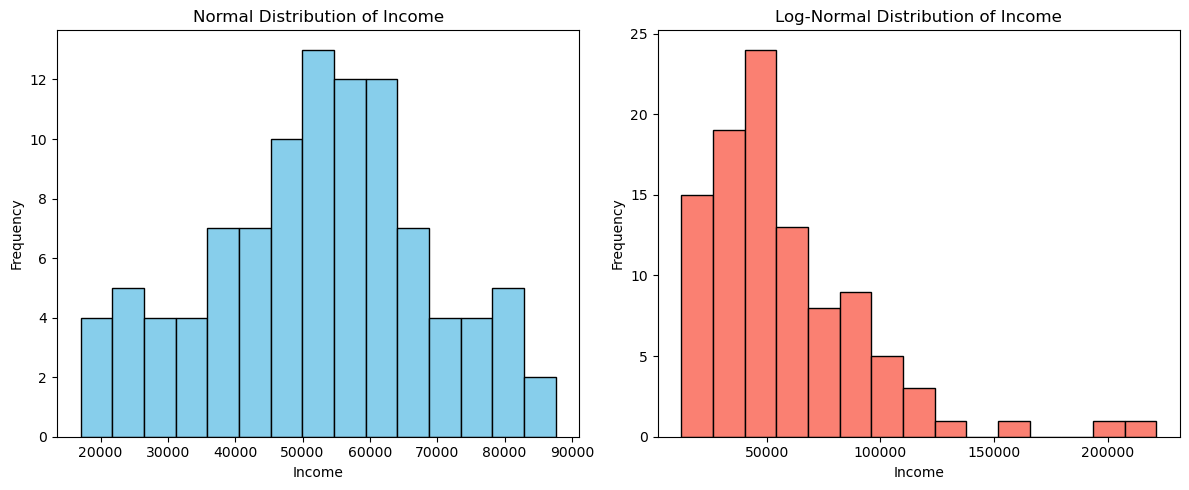

In [33]:
df = pd.DataFrame({
    'Income_Normal': income_normal,
    'Income_LogNormal': income_lognorm
})
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['Income_Normal'], bins=15, color='skyblue', edgecolor='black')
plt.title('Normal Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.hist(df['Income_LogNormal'], bins=15, color='salmon', edgecolor='black')
plt.title('Log-Normal Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [34]:
mean_normal = df['Income_Normal'].mean()
median_normal = df['Income_Normal'].median()

mean_lognorm = df['Income_LogNormal'].mean()
median_lognorm = df['Income_LogNormal'].median()

In [32]:
print(f"Normal Income -> Mean: {mean_normal:.2f}, Median: {median_normal:.2f}")
print(f"Log-Normal Income -> Mean: {mean_lognorm:.2f}, Median: {median_lognorm:.2f}")

Normal Income -> Mean: 52323.50, Median: 53641.04
Log-Normal Income -> Mean: 58294.97, Median: 49318.27
